In [1]:
print("Analysis of Student Grades")

Analysis of Student Grades


In [2]:
print("Looks like fun!")

Looks like fun!


In [3]:
from pathlib import Path

In [27]:
base_dir = Path.cwd()
csv_path  = base_dir/"student_grades.csv"

In [5]:
import pandas as pd#imports pandas package and gives it an alias of pd

In [28]:
#call the read_csv function (pandas)
#load the content of the csv file into a dataframe(df)
#a dataframe is a 2 dimensional view of the csv file
grades = pd.read_csv(csv_path)

In [9]:
grades.head()#shows the first 5 rows of a dataframe

,Name,Class,Grade
0,Alice,Math,88
1,Bob,Math,92
2,Charlie,Science,85
3,Dana,Math,76
4,Eli,Science,90


In [10]:
grades.info()#print a summary of dataframe info

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    5 non-null      str  
 1   Class   5 non-null      str  
 2   Grade   5 non-null      int64
dtypes: int64(1), str(2)
memory usage: 252.0 bytes


In [11]:
grades.shape #how many rows and columns

(5, 3)

In [12]:
grades.describe()#summary statisics of numeric columns

,Grade
count,5.00000
mean,86.20000
std,6.26099
min,76.00000
25%,85.00000
50%,88.00000
75%,90.00000
max,92.00000


In [13]:
grades["Class"].unique()#unique values in that column

<StringArray>
['Math', 'Science']
Length: 2, dtype: str

In [14]:
#show only the math records
math_grades = grades[grades["Class"] == "Math"]
math_grades

,Name,Class,Grade
0,Alice,Math,88
1,Bob,Math,92
3,Dana,Math,76


In [15]:
#count of math students
math_grades.shape[0]

3

In [16]:
#sort dataframe highest to lowest grade of math grades
top_math = math_grades.sort_values(by = "Grade", ascending = False)
top_math

,Name,Class,Grade
1,Bob,Math,92
0,Alice,Math,88
3,Dana,Math,76


In [17]:
#Top math student
top_math.iloc[0]

Name      Bob
Class    Math
Grade      92
Name: 1, dtype: object

In [18]:
#Exercise!
#get the science grades and display them
#Sort the science grades from highest to lowest
#Display the row with the highest science grade


In [20]:
science_grades = grades[grades["Class"] == "Science"]
science_grades

,Name,Class,Grade
2,Charlie,Science,85
4,Eli,Science,90


In [21]:
top_science = science_grades.sort_values(by = "Grade", ascending = False)
top_science

,Name,Class,Grade
4,Eli,Science,90
2,Charlie,Science,85


In [22]:
top_science.iloc[0]

Name         Eli
Class    Science
Grade         90
Name: 4, dtype: object

In [30]:
#print the record of the third highest grade
top_grades = grades.sort_values(by = "Grade", ascending = False)
top_grades.iloc[2]

Name     Alice
Class     Math
Grade       88
Name: 0, dtype: object

In [32]:
#print rows 2,3,and 4 from top_grades
top_grades[1:4]

,Name,Class,Grade
4,Eli,Science,90
0,Alice,Math,88
2,Charlie,Science,85


In [60]:
#first 3 rows of top_grades
top_grades[:3]

    Name    Class  Grade
1    Bob     Math     92
4    Eli  Science     90
0  Alice     Math     88


In [35]:
#just the name of the person with the third highest grade
top_grades.iloc[2]["Name"]

'Alice'

In [37]:
#top 3 records
grades.head(3)


,Name,Class,Grade
0,Alice,Math,88
1,Bob,Math,92
2,Charlie,Science,85


In [38]:
#last 3 rows
grades.tail(3)

,Name,Class,Grade
2,Charlie,Science,85
3,Dana,Math,76
4,Eli,Science,90


In [42]:
#RECORDS where the grade is between 80 and 90
filtered_df = grades[(grades["Grade"] >=80) & (grades["Grade"] <= 90)]
filtered_df


,Name,Class,Grade
0,Alice,Math,88
2,Charlie,Science,85
4,Eli,Science,90


In [44]:
#records with grades of 85 or 88
filtered_df = grades[(grades["Grade"] == 85) | (grades["Grade"] == 88)]
filtered_df

,Name,Class,Grade
0,Alice,Math,88
2,Charlie,Science,85


In [47]:
#A short way
filtered_df = grades[grades["Grade"].isin([85,88])]

In [48]:
#number of students in each class?
#How many values are there for each class
grades["Class"].value_counts()

Class
Math       3
Science    2
Name: count, dtype: int64

In [51]:
#average mark for each class
avg_by_class = grades.groupby("Class")["Grade"].mean().rename("AveragGrade")
avg_by_class

Class
Math       85.333333
Science    87.500000
Name: AveragGrade, dtype: float64

In [ ]:
#Charts

In [52]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Average Grade')

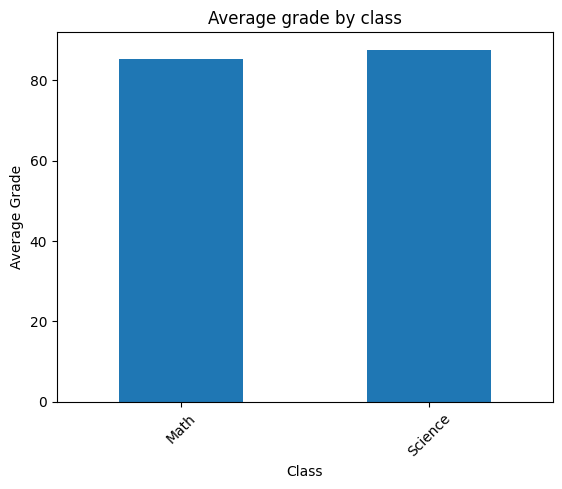

In [56]:
#average mark bar chart by class
avg_by_class.plot(kind = "bar", title = "Average grade by class")
plt.xticks(rotation = 45)
plt.ylabel("Average Grade") 


<Axes: title={'center': 'Students per class'}>

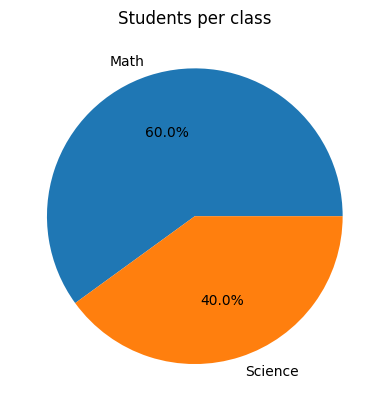

In [59]:
# % → start formatting
# 1.1f →
# 1 = minimum width (not very important here)
# .1 = 1 decimal place
# f = floating point number
# %% → literal % sign (you need two % to show one %)

#pie chart of percent of students in each class
grades["Class"].value_counts().plot(kind = "pie", autopct = "%1.1f%%", title = "Students per class")
